# 📥 Notebook 00: Recolección de Datos

**Proyecto:** Sistema de Detección de Phishing con Machine Learning  
**Autor:** [Tu Nombre]  
**Universidad:** [Tu Universidad]  
**Fecha:** 2024-2025

---

## Objetivos

1. ✅ Descargar URLs de phishing desde **PhishTank**
2. ✅ Recolectar URLs legítimas de **sitios web peruanos**
3. ✅ Extraer las **56 características** de cada URL
4. ✅ Crear dataset combinado listo para análisis

---

## 1. Importar Librerías

In [1]:
import sys
import os

# Agregar directorio src al path
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Módulos propios
from data_collection import DataCollectionManager
from feature_extraction import URLFeatureExtractor

# Configuración
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("✓ Librerías importadas exitosamente")

2025-11-19 17:39:23,137 - root - WARNING - Librería 'tld' no disponible. Algunas features estarán limitadas.


✓ Librerías importadas exitosamente


## 2. Recolección de URLs

### 2.1 Descargar desde PhishTank

In [2]:
# Inicializar manager de recolección
data_manager = DataCollectionManager(data_dir='../data/external')

print("Recolectando datos de PhishTank y URLs peruanas...")
print("Esto puede tomar algunos minutos...\n")

# Recolectar datos (validate_peru_urls=False para ser más rápido)
df_phishing, df_legitimate = data_manager.collect_all_data(validate_peru_urls=False)

print(f"\n✓ Datos recolectados exitosamente")
print(f"  - URLs de phishing (PhishTank): {len(df_phishing)}")
print(f"  - URLs legítimas (Perú): {len(df_legitimate)}")

2025-11-19 17:39:23,388 - data_collection - INFO - PhishTankCollector inicializado. Directorio: ../data/external


2025-11-19 17:39:23,388 - data_collection - INFO - PeruLegitimateURLCollector inicializado. Directorio: ../data/external


2025-11-19 17:39:23,388 - data_collection - INFO - DataCollectionManager inicializado


2025-11-19 17:39:23,388 - data_collection - INFO - === Iniciando recolección completa de datos ===


2025-11-19 17:39:23,388 - data_collection - INFO - Descargando datos de PhishTank...


...

2025-11-19 17:39:25,421 - data_collection - INFO - Categorías: {'gobierno': 12, 'universidades': 12, 'bancos': 10, 'ecommerce': 10, 'medios': 10, 'servicios': 8}


2025-11-19 17:39:25,421 - data_collection - INFO - === Recolección completada ===


2025-11-19 17:39:25,421 - data_collection - INFO - Total URLs de phishing: 48876


2025-11-19 17:39:25,421 - data_collection - INFO - Total URLs legítimas: 62



✓ Datos recolectados exitosamente
  - URLs de phishing (PhishTank): 48876
  - URLs legítimas (Perú): 62


### 2.2 Visualizar Datos Recolectados

In [3]:
# URLs de phishing
print("=" * 60)
print("URLs DE PHISHING (PhishTank)")
print("=" * 60)
print(df_phishing.head(10))
print(f"\nTotal: {len(df_phishing)} URLs\n")

# URLs legítimas
print("=" * 60)
print("URLs LEGÍTIMAS (Perú)")
print("=" * 60)
print(df_legitimate.head(10))
print(f"\nTotal: {len(df_legitimate)} URLs")

# Distribución por categoría (solo URLs peruanas)
if 'category' in df_legitimate.columns:
    print("\n" + "=" * 60)
    print("DISTRIBUCIÓN POR CATEGORÍA (URLs Peruanas)")
    print("=" * 60)
    print(df_legitimate['category'].value_counts())

URLs DE PHISHING (PhishTank)
                                                 url  label     source  \
0   https://app.atendimentoresgateonline.info/inicio      1  PhishTank   
1  https://solucoesaumento.s3.us-east-005.backbla...      1  PhishTank   
2  https://app.atendimentoresgateonline.digital/i...      1  PhishTank   
3                https://app.ativachave.click/inicio      1  PhishTank   
4  http://allegrolokalnie.pl-oferta-kategorie-pol...      1  PhishTank   
5   http://allegrolokalnie.9999-64494847333ssad.cyou      1  PhishTank   
6       https://app.atendimentoresgate.online/inicio      1  PhishTank   
7   https://app.atendimentoresgateonline.life/inicio      1  PhishTank   
8                  http://allegrolokalnie.pl3485.cfd      1  PhishTank   
9                    https://ww25.bancoprovincia.sbs      1  PhishTank   

  collection_date  
0      2025-11-19  
1      2025-11-19  
2      2025-11-19  
3      2025-11-19  
4      2025-11-19  
5      2025-11-19  
6      2025-11-1

### 2.3 Gráfica de Distribución

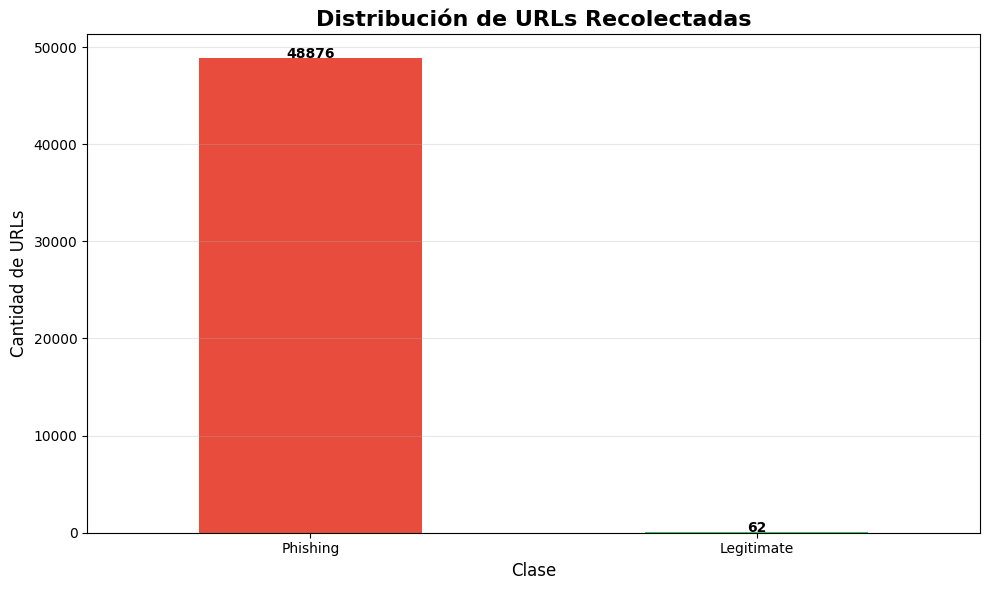

Total de URLs recolectadas: 48938


In [4]:
# Gráfica de distribución de clases
class_counts = pd.Series({
    'Phishing': len(df_phishing),
    'Legitimate': len(df_legitimate)
})

plt.figure(figsize=(10, 6))
class_counts.plot(kind='bar', color=['#e74c3c', '#2ecc71'])
plt.title('Distribución de URLs Recolectadas', fontsize=16, fontweight='bold')
plt.xlabel('Clase', fontsize=12)
plt.ylabel('Cantidad de URLs', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

# Agregar valores en las barras
for i, v in enumerate(class_counts):
    plt.text(i, v + 50, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Total de URLs recolectadas: {len(df_phishing) + len(df_legitimate)}")

## 3. Extracción de Features

Ahora vamos a extraer las **56 características** de cada URL.

In [5]:
# Inicializar extractor de features
extractor = URLFeatureExtractor()

print("Extrayendo features de URLs de phishing...")
df_phishing_features = extractor.extract_features_batch(
    df_phishing['url'].tolist(),
    show_progress=True
)
df_phishing_features['label'] = 1  # 1 = phishing

print("\nExtrayendo features de URLs legítimas...")
df_legitimate_features = extractor.extract_features_batch(
    df_legitimate['url'].tolist(),
    show_progress=True
)
df_legitimate_features['label'] = 0  # 0 = legítimo

print("\n✓ Extracción de features completada")

2025-11-19 17:39:25,795 - feature_extraction - INFO - URLFeatureExtractor inicializado


2025-11-19 17:39:25,797 - feature_extraction - INFO - Extrayendo features de 48876 URLs...


Extrayendo features de URLs de phishing...


Extrayendo features:   0%|          | 0/48876 [00:00<?, ?it/s]

Extrayendo features:   2%|▏         | 956/48876 [00:00<00:05, 8973.28it/s]

...


Extrayendo features de URLs legítimas...


Extrayendo features:   0%|          | 0/62 [00:00<?, ?it/s]

Extrayendo features: 100%|██████████| 62/62 [00:00<?, ?it/s]


2025-11-19 17:39:32,237 - feature_extraction - INFO - Features extraídas: (62, 57)



✓ Extracción de features completada


### 3.1 Verificar Features Extraídas

In [6]:
print("=" * 60)
print("FEATURES EXTRAÍDAS")
print("=" * 60)
print(f"Total de features: {len(df_phishing_features.columns) - 2}")  # -2 por 'url' y 'label'
print(f"\nNombres de features:")
feature_names = [col for col in df_phishing_features.columns if col not in ['url', 'label']]
for i, name in enumerate(feature_names, 1):
    print(f"  {i:2d}. {name}")

print(f"\n✓ Total de {len(feature_names)} features extraídas exitosamente")

FEATURES EXTRAÍDAS
Total de features: 56

Nombres de features:
   1. url_length
   2. domain_length
   3. path_length
   4. count_dots
   5. count_hyphens
   6. count_underscores
   7. count_slashes
   8. count_question_marks
   9. count_equal_signs
  10. count_at_signs
  11. count_ampersands
  12. count_digits
  13. count_letters
  14. count_special_chars
  15. has_ip_address
  16. count_subdomains
  17. domain_has_hyphen
  18. has_suspicious_tld
  19. is_https
  20. has_port
  21. count_path_segments
  22. count_query_parameters
  23. has_fragment
  24. count_suspicious_words
  25. has_login_word
  26. has_verify_word
  27. url_entropy
  28. domain_entropy
  29. path_entropy
  30. digit_letter_ratio
  31. special_char_ratio
  32. has_double_slash_redirect
  33. abnormal_url_length
  34. tiny_url_length
  35. prefix_suffix_domain
  36. count_www
  37. count_com
  38. count_double_slash
  39. count_https_token
  40. count_http_token
  41. ratio_digits_url
  42. ratio_digits_domain
  43

### 3.2 Visualizar Ejemplos de Features

In [7]:
# Mostrar primeras filas
print("Ejemplos de URLs de Phishing con Features:\n")
print(df_phishing_features.head())

print("\n" + "=" * 60)
print("\nEjemplos de URLs Legítimas con Features:\n")
print(df_legitimate_features.head())

Ejemplos de URLs de Phishing con Features:

   url_length  domain_length  path_length  count_dots  count_hyphens  \
0          48             33            7           2              0   
1          67             46           13           5              2   
2          51             36            7           2              0   
3          35             20            7           2              0   
4          63             56            0           2              3   

   count_underscores  count_slashes  count_question_marks  count_equal_signs  \
0                  0              3                     0                  0   
1                  0              3                     0                  0   
2                  0              3                     0                  0   
3                  0              3                     0                  0   
4                  0              2                     0                  0   

   count_at_signs  count_ampersands  count

## 4. Combinar y Guardar Dataset

Combinar ambos datasets y guardar el resultado final.

In [8]:
# Combinar datasets
df_combined = pd.concat([df_phishing_features, df_legitimate_features], ignore_index=True)

print("Dataset Combinado:")
print(f"  - Shape: {df_combined.shape}")
print(f"  - Muestras totales: {len(df_combined)}")
print(f"  - Features: {df_combined.shape[1] - 2}")  # -2 por url y label
print(f"\nDistribución de clases:")
print(df_combined['label'].value_counts())
print(f"\n  - Phishing (1): {(df_combined['label'] == 1).sum()}")
print(f"  - Legítimo (0): {(df_combined['label'] == 0).sum()}")

Dataset Combinado:
  - Shape: (48938, 58)
  - Muestras totales: 48938
  - Features: 56

Distribución de clases:
label
1    48876
0       62
Name: count, dtype: int64

  - Phishing (1): 48876
  - Legítimo (0): 62


In [9]:
# Guardar dataset combinado
from datetime import datetime

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
output_path = f'../data/external/features_extracted_{timestamp}.csv'

df_combined.to_csv(output_path, index=False)

print(f"✓ Dataset guardado exitosamente en:")
print(f"  {output_path}")
print(f"\nTamaño del archivo: {os.path.getsize(output_path) / (1024*1024):.2f} MB")

✓ Dataset guardado exitosamente en:
  ../data/external/features_extracted_20251119_173932.csv

Tamaño del archivo: 13.20 MB


## 5. Análisis Preliminar de Features

Veamos algunas estadísticas básicas de las features extraídas.

In [10]:
# Separar features de labels
X = df_combined.drop(['url', 'label'], axis=1)
y = df_combined['label']

# Estadísticas descriptivas
print("=" * 60)
print("ESTADÍSTICAS DESCRIPTIVAS")
print("=" * 60)
print(X.describe())

ESTADÍSTICAS DESCRIPTIVAS
         url_length  domain_length   path_length    count_dots  count_hyphens  \
count  48938.000000   48938.000000  48938.000000  48938.000000   48938.000000   
mean      65.545915      19.982692     22.515080      2.059218       0.849790   
std      177.689989      12.901397     35.876355      1.171384       1.394884   
min       12.000000       4.000000      0.000000      1.000000       0.000000   
25%       27.000000      11.000000      1.000000      2.000000       0.000000   
50%       40.000000      17.000000      7.000000      2.000000       0.000000   
75%       69.000000      25.000000     22.000000      2.000000       1.000000   
max    25523.000000     166.000000    997.000000     59.000000      50.000000   

       count_underscores  count_slashes  count_question_marks  \
count       48938.000000   48938.000000          48938.000000   
mean            0.249397       3.855143              0.215906   
std             1.077452       1.648966          

### 5.1 Comparación de Features entre Phishing y Legítimas

C:\Users\arley\AppData\Local\Temp\ipykernel_14440\3996817869.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([legitimate_data, phishing_data], labels=['Legitimate', 'Phishing'])
C:\Users\arley\AppData\Local\Temp\ipykernel_14440\3996817869.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([legitimate_data, phishing_data], labels=['Legitimate', 'Phishing'])
C:\Users\arley\AppData\Local\Temp\ipykernel_14440\3996817869.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([legitimate_data, phishing_data], labels=['Legitimate', 'Phishing'])
C:\Users\arley\AppData\Local\Temp\ipykernel

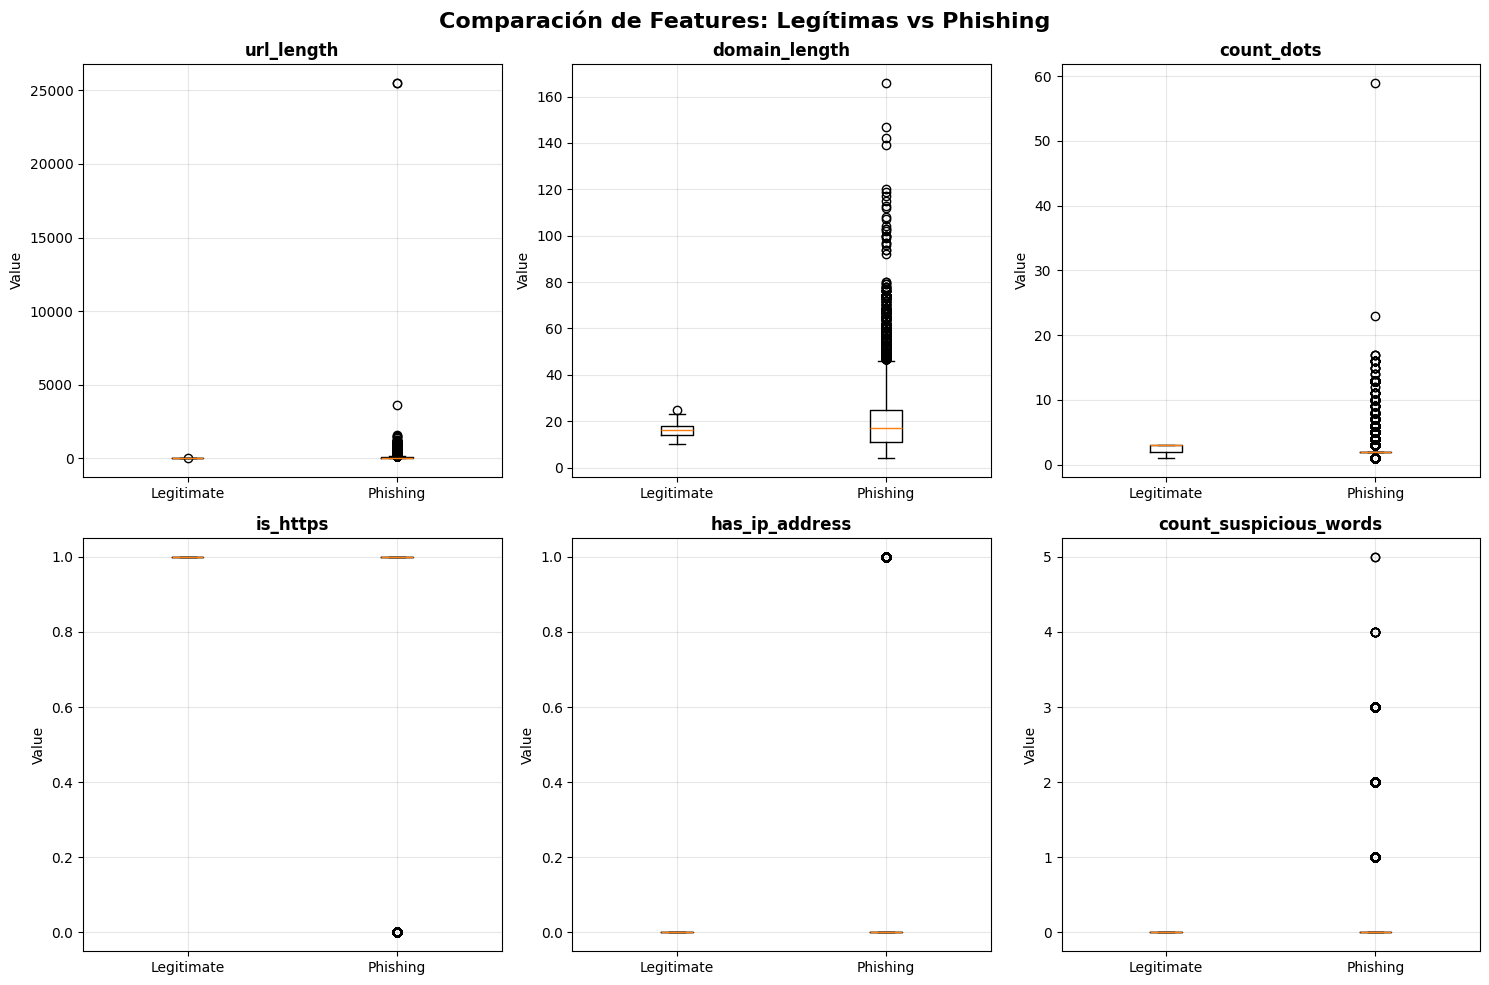

In [11]:
# Seleccionar algunas features interesantes para comparar
features_to_compare = [
    'url_length',
    'domain_length',
    'count_dots',
    'is_https',
    'has_ip_address',
    'count_suspicious_words'
]

# Crear figura con subplots
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, feature in enumerate(features_to_compare):
    ax = axes[idx]
    
    # Datos por clase
    phishing_data = df_combined[df_combined['label'] == 1][feature]
    legitimate_data = df_combined[df_combined['label'] == 0][feature]
    
    # Boxplot
    ax.boxplot([legitimate_data, phishing_data], labels=['Legitimate', 'Phishing'])
    ax.set_title(feature, fontweight='bold')
    ax.set_ylabel('Value')
    ax.grid(alpha=0.3)

plt.suptitle('Comparación de Features: Legítimas vs Phishing', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Resumen Final

In [12]:
print("="*70)
print("                    RESUMEN DE RECOLECCIÓN DE DATOS")
print("="*70)
print(f"\n✓ URLs de Phishing (PhishTank):     {len(df_phishing):,}")
print(f"✓ URLs Legítimas (Perú):            {len(df_legitimate):,}")
print(f"✓ Total de URLs recolectadas:       {len(df_combined):,}")
print(f"\n✓ Features extraídas por URL:       {len(feature_names)}")
print(f"✓ Dataset final guardado en:        {output_path}")
print(f"\n{'='*70}")
print("\n🎉 RECOLECCIÓN DE DATOS COMPLETADA EXITOSAMENTE")
print("\n📌 Próximo paso: Notebook 01 - Exploración de Datos (EDA)")
print("="*70)

                    RESUMEN DE RECOLECCIÓN DE DATOS

✓ URLs de Phishing (PhishTank):     48,876
✓ URLs Legítimas (Perú):            62
✓ Total de URLs recolectadas:       48,938

✓ Features extraídas por URL:       56
✓ Dataset final guardado en:        ../data/external/features_extracted_20251119_173932.csv


🎉 RECOLECCIÓN DE DATOS COMPLETADA EXITOSAMENTE

📌 Próximo paso: Notebook 01 - Exploración de Datos (EDA)
